# $-u'' + u^3 = f$ with Dirichlet and Neumann conditions, Newton's method, cubic splines

We solve the nonlinear problem

$$-u''(x) + u(x)^3 = f(x), \quad 0 < x < 1, \qquad u(0) = 1, \quad u'(1) = g,$$

with the exact solution $u(x) = 1 + x + \sin(\pi x)$, so that $f(x) = \pi^2 \sin(\pi x) + \left(1 + x + \sin(\pi x)\right)^3$ and $g = u'(1) = 1 - \pi$.

As in `example1`, integrating by parts against a test function $v$ with $v(0) = 0$ gives the weak form as a **residual**: find $u$ with $u(0) = 1$ such that

$$R(u; v) = \int_0^1 \left(u' v' + u^3 v - f v\right) dx - g\, v(1) = 0$$

for every test function $v$ that vanishes at $x = 0$. Newton's method solves $J(u)\,\delta = -R(u)$ and updates $u \leftarrow u + \delta$, where $J = \partial R / \partial u$ is the Jacobian. `fd.newton` computes $J$ exactly from the form, symbolically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import D, dx, ds

Cubic splines on 20 equal elements, Dirichlet at the left end with its value $u(0) = 1$ given with the space, and the right end free for the natural Neumann condition.

In [2]:
grid = np.linspace(0, 1, 101)
V = fd.SplineSpace(grid, 3, bc=("dirichlet", "free"), left=1.0)
v = fd.TestFunction(V)

The unknown is a `Function` of `V.unconstrained`, the space with nothing built in, so that it can hold the boundary value $u(0) = 1$. It also holds the initial guess, here zero: Newton puts the boundary value in before the first iteration.

In [3]:
u = fd.Function(V.unconstrained, "u")
u.vector[:] = 1.0

The residual is a form linear in the test function $v$ and nonlinear in the unknown $u$. The Neumann data enter through the term `g * v * ds("right")`, the point value $g\,v(1)$.

In [4]:
f = np.pi**2 * fd.sin(np.pi * fd.x) + (1 + fd.x + fd.sin(np.pi * fd.x))**3
g = 1 - np.pi

R = fd.form((D(u) * D(v) + u**3 * v - f * v) * dx - g * v * ds("right"))

`fd.newton` with its defaults is the full Newton method with the exact Jacobian and a backtracking line search. Each iteration

1. assembles the residual vector $r = R(u)$,
2. assembles the exact Jacobian $J(u)$, obtained by differentiating the form symbolically: here $J(u)[w, v] = \int_0^1 \left(w' v' + 3u^2 w v\right) dx$, recomputed at every iterate,
3. solves $J\,\delta = -r$ with a direct banded solver (the banded Cholesky, since $J$ is symmetric positive definite here),
4. halves the step length $s$, starting from $s = 1$, until $\|R(u + s\,\delta)\| \le (1 - 10^{-4} s)\,\|R(u)\|$ (Armijo backtracking), and sets $u \leftarrow u + s\,\delta$.

It stops when $\|R\| \le 10^{-10}$ (`tol`). The boundary value comes from the space, and `u` is updated in place.

In [5]:
info = fd.newton(R, u)      # defaults: exact Jacobian, direct banded solve, line_search=True, tol=1e-10
print(info)
for k, r in enumerate(info.residuals):
    print(f"iteration {k}:  ||R|| = {r:.2e}")


NewtonInfo(converged in 5 iterations, ||R|| 2.76e+00 -> 9.53e-14)
iteration 0:  ||R|| = 2.76e+00
iteration 1:  ||R|| = 1.12e+00
iteration 2:  ||R|| = 1.76e-02
iteration 3:  ||R|| = 5.56e-05
iteration 4:  ||R|| = 7.19e-10
iteration 5:  ||R|| = 9.53e-14


**A check with the complex-step Newton-Krylov method.** `fd.newton` can also solve without forming the Jacobian. With `linear="gmres"` each Newton system is solved by GMRES, and with `jv="complex-step"` the products $J v = \operatorname{Im} R(u + i h v) / h$ are computed from the residual itself ($h = 10^{-20}$, exact to rounding). With no preconditioner and full steps this is the method of the vendored `csnewton`, and it checks the symbolic Jacobian and the whole solve independently. The boundary data are handled as before, from the space.

In [6]:
w = fd.Function(V.unconstrained, "w")          # a second unknown, so that u keeps the first solution
Rw = fd.form((D(w) * D(v) + w**3 * v - f * v) * dx - g * v * ds("right"))

csinfo = fd.newton(Rw, w, linear="lgmres",       # GMRES for each Newton system
                   jv="complex-step",           # J v = Im R(w + i h v) / h, no Jacobian formed
                   precond="frozen",               
                   restart=10, tol=1e-10,
                   line_search=True)           
print(csinfo)
for k, r in enumerate(info.residuals):
    print(f"iteration {k}:  ||R|| = {r:.2e}")

xs = np.linspace(0, 1, 401)
print("max |u_newton - u_complex_step|:", np.max(np.abs(u(xs) - w(xs))))

NewtonInfo(converged in 8 iterations, ||R|| 2.15e+02 -> 1.66e-13, 22 Krylov iterations)
iteration 0:  ||R|| = 2.76e+00
iteration 1:  ||R|| = 1.12e+00
iteration 2:  ||R|| = 1.76e-02
iteration 3:  ||R|| = 5.56e-05
iteration 4:  ||R|| = 7.19e-10
iteration 5:  ||R|| = 9.53e-14
max |u_newton - u_complex_step|: 1.0347278589506459e-13


Compare with the exact solution: the maximum error, sampled on 401 points, and the $L^2$ error, $\|u_h - u\|_{L^2} = \left(\int_0^1 (u_h - u)^2\,dx\right)^{1/2}$, integrated by quadrature on each element.

max error: 1.3532082121514577e-09
L2 error:  6.265541510656549e-10
u'(1) = -2.1415926526258495   exact: -2.141592653589793


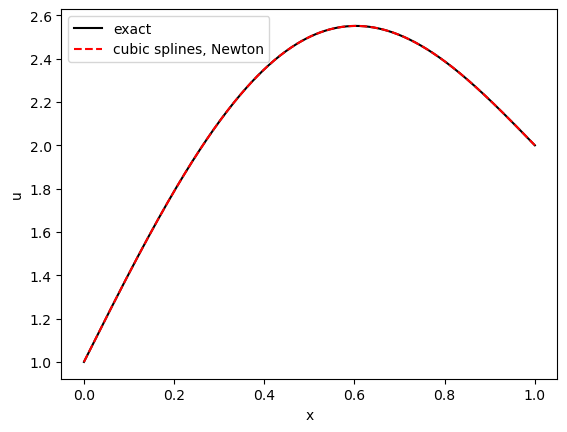

In [7]:
xs = np.linspace(0, 1, 401)
exact = 1 + xs + np.sin(np.pi * xs)
errinf = np.max(np.abs(u(xs) - exact))
print("max error:", errinf)

uex = 1 + fd.x + fd.sin(np.pi * fd.x)             # the exact solution as an expression in x
errL2 = np.sqrt(fd.form((u - uex)**2 * dx).assemble())
print("L2 error: ", errL2)
print("u'(1) =", u(1.0, 1).item(), "  exact:", g)

plt.plot(xs, exact, "k-", label="exact")
plt.plot(xs, u(xs), "r--", label="cubic splines, Newton")
plt.xlabel("x"); plt.ylabel("u"); plt.legend()
plt.show()